In [12]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [13]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 12
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

font_path = os.path.join('..', 'other', 'Roboto', 'Roboto-Regular.ttf')
font_prop = FontProperties(fname = font_path)
fm.fontManager.addfont(font_path)
custom_font_name = font_prop.get_name()

font_path_bold = os.path.join('..', 'other', 'Roboto', 'Roboto-Bold.ttf')
font_prop_bold = FontProperties(fname = font_path_bold)

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = custom_font_name
plt.rcParams['axes.unicode_minus'] = True

In [14]:
results_file = 'overall.xlsx'

In [15]:
economics_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'economics', index_col = 0)
economics_df_final = economics_df.drop(columns = 'Total')
economics_df_final

,Scenario,Ammonia,Electricity,Heating utilities,Cooling utilities,CAPEX,Direct emissions
0,BAU,0.651278,0.046687,0.001717,0.002133,0.139513,0
1,AON 84%,0.705260,0.005613,0.000000,0.002706,0.037448,0
2,AON 100%,0.595943,0.004288,0.000000,0.002308,0.032696,0
3,BAU,1.221782,0.046687,0.001717,0.002133,0.139513,0
4,AON 84%,1.323051,0.005613,0.000000,0.002706,0.037448,0
5,AON 100%,1.117975,0.004288,0.000000,0.002308,0.032696,0


In [16]:
climate_change_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change', index_col = 0)
climate_change_df_final = climate_change_df.drop(columns = 'Total')
climate_change_df_final

,Scenario,Ammonia,Electricity,Heating utilities,Cooling utilities,CAPEX,Direct emissions
0,BAU,3.043367,0.371490,0.020039,0.005483,0,-2.530296e-08
1,AON 84%,3.295620,0.044662,0.000000,0.002669,0,5.142144e-08
2,AON 100%,2.784792,0.034123,0.000000,0.002276,0,0.000000e+00
3,BAU,0.728015,0.371490,0.020039,0.005483,0,-2.530296e-08
4,AON 84%,0.788357,0.044662,0.000000,0.002669,0,5.142144e-08
5,AON 100%,0.666160,0.034123,0.000000,0.002276,0,0.000000e+00


In [17]:
x_pts = np.arange(0, len(climate_change_df_final))
x_labels = []
for i in range(0, len(x_pts)):
    string = climate_change_df_final['Scenario'][i]
    new = '\n'
    string = new.join(string.rsplit(' ', 1))
    x_labels.append(string)
x_labels

['BAU', 'AON\n84%', 'AON\n100%', 'BAU', 'AON\n84%', 'AON\n100%']

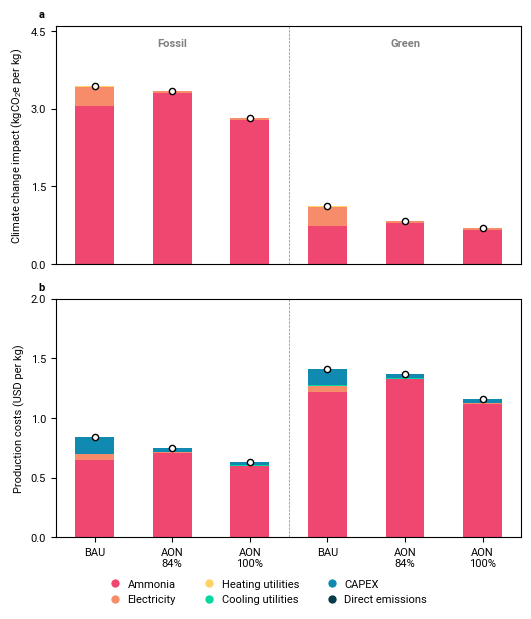

In [46]:
fig, [ax1, ax2] = plt.subplots(2, 1, figsize = (fig_length[1.5], fig_height*0.6))

colors = ['#ef476f', '#f78c6b', '#ffd166', '#06d6a0', '#118ab2', '#073b4c'] 

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impact (kgCO$_\mathdefault{2}$e per kg)')
ax1.set_xticks(x_pts)  
ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax1.scatter(x_pts, climate_change_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax1.set_title('a', fontproperties = font_prop_bold, x = -0.03)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5, zorder = 0)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax1.set_ylim([0, 4.6])
ax1.text(1, 4.2, 'Fossil', ha = 'center', color = '#808080', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.text(4, 4.2, 'Green', ha = 'center', color = '#808080', fontweight = 'bold', fontproperties = font_prop_bold)
ax1.yaxis.set_major_locator(MaxNLocator(4))
ax1.set_xticks([])

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
ax2.legend([], frameon = False)
ax2.set_ylabel('Production costs (USD per kg)')
ax2.set_xticks(x_pts)  
ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
ax2.scatter(x_pts, economics_df['Total'], s = 20, facecolor = 'white', edgecolors = '#000000')
ax2.set_title('b', fontproperties = font_prop_bold, x = -0.03)
ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax2.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 0.5)
ax2.set_ylim([0.0, 2.0])
# ax2.text(1.5, 4.6, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax2.text(5.5, 4.6, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
ax2.yaxis.set_major_locator(MaxNLocator(4))

labels = ['Ammonia', 'Electricity', 'Heating utilities', 'Cooling utilities', 'CAPEX', 'Direct emissions']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 7) for color in colors]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 5, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#8763c9', markersize = 5, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 3, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'plots', 'main_figure')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)

In [ ]:
# climate_change_df_2050 = pd.read_excel(os.path.join('..', 'results', climate_change_results_file), sheet_name = 'overall_2050', index_col = 0)
# climate_change_df_2050_final = climate_change_df_2050.drop(columns = 'Total')
# climate_change_df_2050_final

,Scenario,Coke,Methane,Heating,Electricity,Other utilities,Direct emissions
0,Calcium carbide,1.838287,0.000000,0.000000,7.337633,0.172487,3.601439
1,Partial oxidation,0.000000,3.135920,1.569122,2.239700,0.067908,0.800000
2,Hot plasma,0.000000,1.092655,1.394776,8.217214,0.064981,0.000000
3,Cold plasma,0.000000,1.040624,0.000000,8.590724,0.000000,0.000000
4,Calcium carbide,1.628990,0.000000,0.000000,-0.483549,0.029069,3.601440
5,Partial oxidation,0.000000,2.767090,1.439968,-0.147596,0.039739,0.800000
6,Hot plasma,0.000000,0.964143,1.279971,-0.541513,0.037783,0.000000
7,Cold plasma,0.000000,0.918231,0.000000,-0.566128,0.000000,0.000000


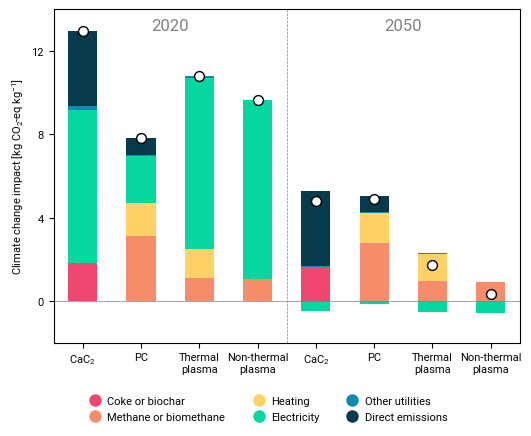

In [ ]:
# fig, ax1 = plt.subplots(1, 1, figsize = (fig_length[1.5], fig_height*0.4))

# climate_change_df_2050_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)

# ax1.legend([], frameon = False)

# ax1.set_ylabel('Climate change impact [kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$]')

# ax1.set_xticks(x_pts)  
# ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
# ax1.scatter(x_pts, climate_change_df_2050['Total'], s = 50, facecolor = 'white', edgecolors = '#000000')
# ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)

# ax1.axvline(x = 3.5, color = '#808080', linestyle = '--', linewidth = 0.5)

# ax1.set_ylim([-2, 14])
# ax1.text(1.5, 13.0, '2020', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax1.text(5.5, 13.0, '2050', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')

# ax1.yaxis.set_major_locator(MaxNLocator(5))
# handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10) for color in colors]
# legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.0), ncol = 3, frameon = False, handletextpad = 0.1)

# filepath = os.path.join('..', 'plots', 'future_electricity_mix')
# plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
# plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)

In [ ]:
# climate_change_df_overall = pd.read_excel(os.path.join('..', 'results', climate_change_results_file), sheet_name = 'overall_combined', index_col = 0)
# climate_change_df_overall_final = climate_change_df_overall.drop(columns = 'Total')
# climate_change_df_overall_final

In [ ]:
# x_pts = np.arange(0, len(climate_change_df_overall_final))
# x_labels = []
# for i in range(0, len(x_pts)):
#     string = climate_change_df_overall_final['Scenario'][i]
#     new = '\n'
#     string = new.join(string.rsplit(' ', 1))
#     x_labels.append(string)
# x_labels

In [ ]:
# economics_df_overall = pd.read_excel(os.path.join('..', 'results', economics_results_file), sheet_name = 'overall_combined', index_col = 0)
# economics_df_overall_final = economics_df_overall.drop(columns = 'Total')
# economics_df_overall_final

In [ ]:
# fig, [ax1, ax2] = plt.subplots(2, 1, figsize = (fig_length[2]*1.2, fig_height*0.8))

# climate_change_df_overall_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors)
# ax1.legend([], frameon = False)
# ax1.set_ylabel('Climate change impact [kg CO$_\mathdefault{2}$-eq kg$^\mathdefault{-1}$]')
# ax1.set_xticks(x_pts)  
# ax1.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
# ax1.scatter(x_pts, climate_change_df_overall['Total'], s = 50, facecolor = 'white', edgecolors = '#000000')
# ax1.set_title('a', fontsize = fontsize_title, fontweight = 'bold')
# ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
# ax1.axvline(x = 4.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax1.axvline(x = 9.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax1.set_ylim([-10, 15.2])
# ax1.text(2.0, 13.5, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax1.text(7.0, 13.5, 'Green (grid)', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax1.text(12.0, 13.5, 'Green (wind)', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax1.yaxis.set_major_locator(MaxNLocator(5))
# ax1.set_xticks([])

# economics_df_overall_final.plot(kind = 'bar', stacked = True, ax = ax2, color = colors)
# ax2.legend([], frameon = False)
# ax2.set_ylabel('Production costs [USD kg$^\mathdefault{-1}$]')
# ax2.set_xticks(x_pts)  
# ax2.set_xticklabels(x_labels, rotation = 0, ha = 'center')  
# ax2.scatter(x_pts, economics_df_overall['Total'], s = 50, facecolor = 'white', edgecolors = '#000000')
# ax2.set_title('b', fontsize = fontsize_title, fontweight = 'bold')
# ax2.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
# ax2.axvline(x = 4.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax2.axvline(x = 9.5, color = '#808080', linestyle = '--', linewidth = 0.5)
# ax2.set_ylim([0.1, 4.9])
# ax2.text(2.0, 4.6, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax2.text(7.0, 4.6, 'Green (grid)', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax2.text(12.0, 4.6, 'Green (wind)', ha = 'center', color = '#808080', fontsize = fontsize_title, fontweight = 'bold')
# ax2.yaxis.set_major_locator(MaxNLocator(5))

# handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10) for color in colors]
# legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.0), ncol = 6, frameon = False, handletextpad = 0.1)

# filepath = os.path.join('..', 'plots', 'main_figure_combined')
# plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 1200)
# plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 1200)